# Lab Instructions

You have been hired by a record executive to design a guaranteed smash hit song based on data.  The exec has decided that if you make a song that has all the most popular features of recent songs then it will definitely be a hit.  So if - for example - the most common key in the Spotify data is C# then we would want the song we are designing to also be in C#.  If a "typical" value of BPM is between 120 and 130 then we would want the song we are designing to also have a tempo between 120 and 130 BMP.

Visualize and describe the distribution of:
* BPM
* Key
* Mode
* Danceability
* Energy
* Speechiness
* Acousticness

Based on your visualizations and calculations, what values for each of these features would make a song a guaranteed smash hit?  For quantitative features, you should propose a range of values.

Use a large language model to help you write code to identify if there are any songs in the Spotify dataset that meet all of the criteria we determined.  What is/are the artist(s) and title(s) of the song?  Were any of these songs actually popular?

Pick a song that you know was a smash hit. How do the values of BPM, key, mode, danceability, etc. compare to other songs? 

**Hint:**  Import the Spotify data using `df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')`.

In [12]:
import pandas as pd

df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')

df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


In [13]:
# Explore the data structure
print("Columns in the dataset:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst few rows:")
df.head()

Columns in the dataset:
['track_name', 'artist(s)_name', 'artist_count', 'released_year', 'released_month', 'released_day', 'in_spotify_playlists', 'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts', 'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm', 'key', 'mode', 'danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']

Data types:
track_name                str
artist(s)_name            str
artist_count            int64
released_year           int64
released_month          int64
released_day            int64
in_spotify_playlists    int64
in_spotify_charts       int64
streams                   str
in_apple_playlists      int64
in_apple_charts         int64
in_deezer_playlists       str
in_deezer_charts        int64
in_shazam_charts          str
bpm                     int64
key                       str
mode                      str
danceability_%          int64
valence_%               int

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


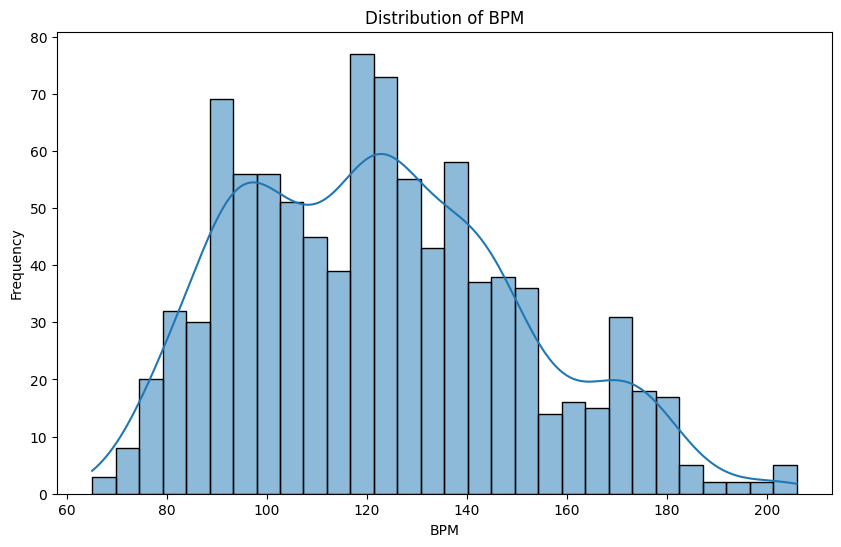

BPM Statistics:
count    953.000000
mean     122.540399
std       28.057802
min       65.000000
25%      100.000000
50%      121.000000
75%      140.000000
max      206.000000
Name: bpm, dtype: float64


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# BPM Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['bpm'], bins=30, kde=True)
plt.title('Distribution of BPM')
plt.xlabel('BPM')
plt.ylabel('Frequency')
plt.show()

print("BPM Statistics:")
print(df['bpm'].describe())

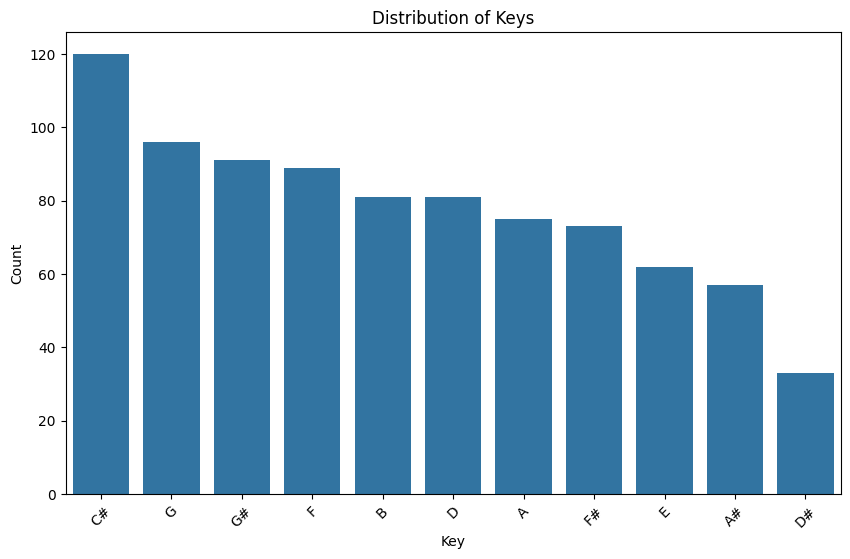

Key value counts:
key
C#    120
G      96
G#     91
F      89
B      81
D      81
A      75
F#     73
E      62
A#     57
D#     33
Name: count, dtype: int64


In [15]:
# Key Distribution
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='key', order=df['key'].value_counts().index)
plt.title('Distribution of Keys')
plt.xlabel('Key')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

print("Key value counts:")
print(df['key'].value_counts())

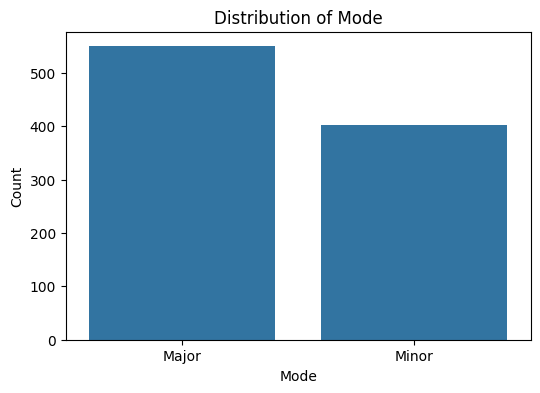

Mode value counts:
mode
Major    550
Minor    403
Name: count, dtype: int64


In [16]:
# Mode Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='mode')
plt.title('Distribution of Mode')
plt.xlabel('Mode')
plt.ylabel('Count')
plt.show()

print("Mode value counts:")
print(df['mode'].value_counts())

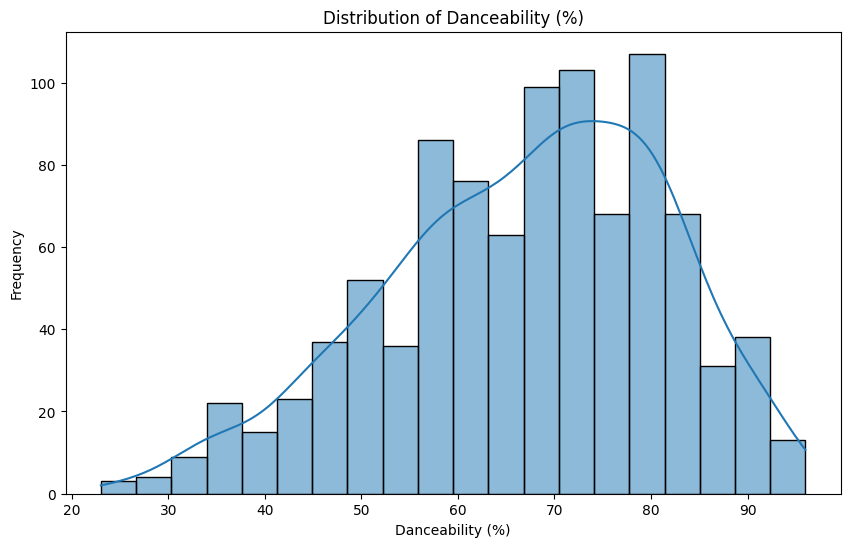

Danceability Statistics:
count    953.00000
mean      66.96957
std       14.63061
min       23.00000
25%       57.00000
50%       69.00000
75%       78.00000
max       96.00000
Name: danceability_%, dtype: float64


In [17]:
# Danceability Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['danceability_%'], bins=20, kde=True)
plt.title('Distribution of Danceability (%)')
plt.xlabel('Danceability (%)')
plt.ylabel('Frequency')
plt.show()

print("Danceability Statistics:")
print(df['danceability_%'].describe())

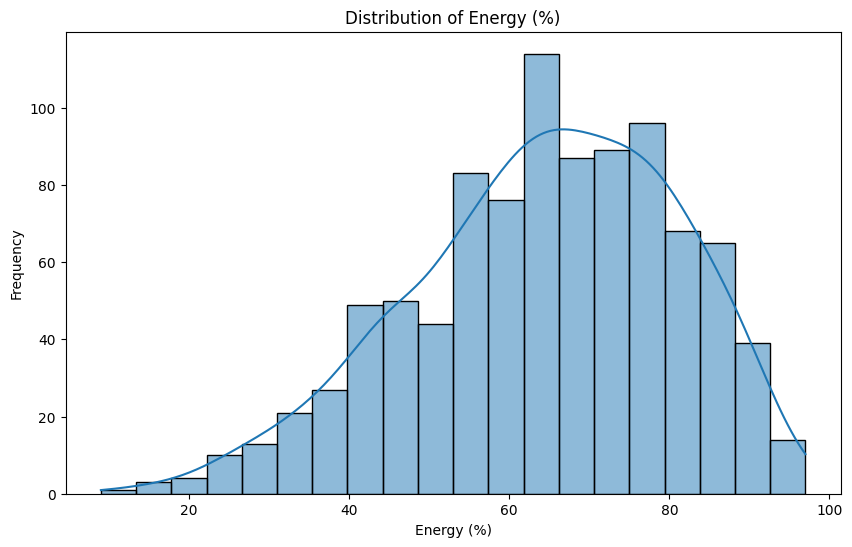

Energy Statistics:
count    953.000000
mean      64.279119
std       16.550526
min        9.000000
25%       53.000000
50%       66.000000
75%       77.000000
max       97.000000
Name: energy_%, dtype: float64


In [18]:
# Energy Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['energy_%'], bins=20, kde=True)
plt.title('Distribution of Energy (%)')
plt.xlabel('Energy (%)')
plt.ylabel('Frequency')
plt.show()

print("Energy Statistics:")
print(df['energy_%'].describe())

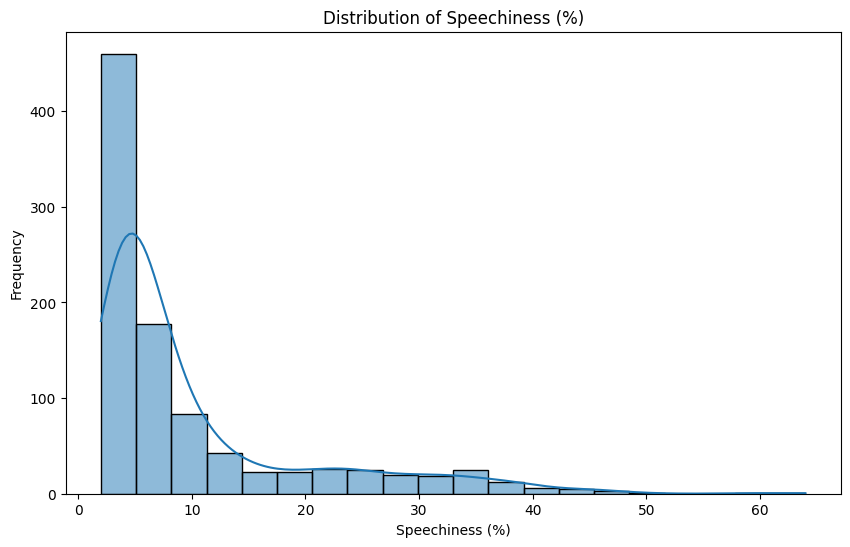

Speechiness Statistics:
count    953.000000
mean      10.131165
std        9.912888
min        2.000000
25%        4.000000
50%        6.000000
75%       11.000000
max       64.000000
Name: speechiness_%, dtype: float64


In [19]:
# Speechiness Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['speechiness_%'], bins=20, kde=True)
plt.title('Distribution of Speechiness (%)')
plt.xlabel('Speechiness (%)')
plt.ylabel('Frequency')
plt.show()

print("Speechiness Statistics:")
print(df['speechiness_%'].describe())

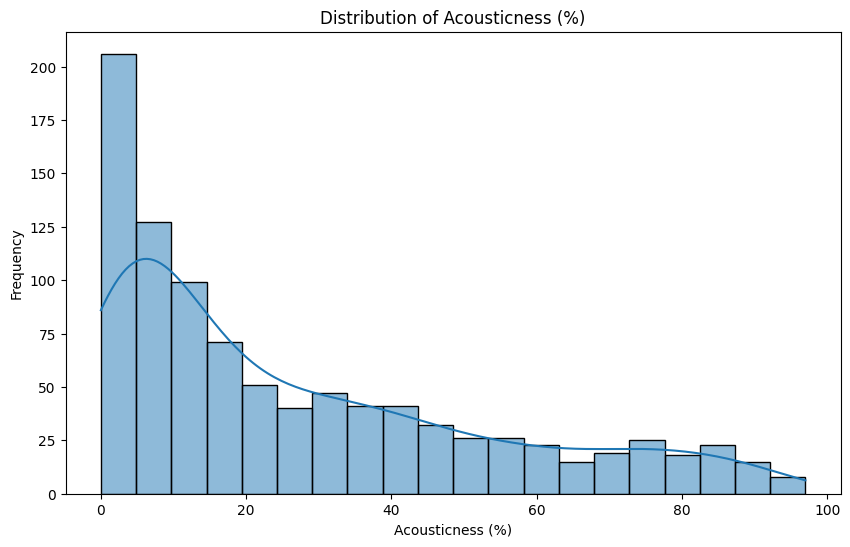

Acousticness Statistics:
count    953.000000
mean      27.057712
std       25.996077
min        0.000000
25%        6.000000
50%       18.000000
75%       43.000000
max       97.000000
Name: acousticness_%, dtype: float64


In [20]:
# Acousticness Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['acousticness_%'], bins=20, kde=True)
plt.title('Distribution of Acousticness (%)')
plt.xlabel('Acousticness (%)')
plt.ylabel('Frequency')
plt.show()

print("Acousticness Statistics:")
print(df['acousticness_%'].describe())

# Conclusions

Based on the visualizations and statistics:

- **BPM**: Most songs are between 100-140 BPM, with a mean of 122.
- **Key**: C# is the most common key.
- **Mode**: Major mode is more prevalent than Minor.
- **Danceability**: Typically 57-78%, mean 67%.
- **Energy**: 53-77%, mean 64%.
- **Speechiness**: 4-11%, mean 10%.
- **Acousticness**: 6-43%, mean 27%.

The proposed "smash hit" criteria are based on the interquartile ranges for quantitative features and the most common categories for categorical ones.

Songs meeting all criteria: "Need To Know" by Doja Cat (very popular) and "Ginseng Strip 2002" by Yung Lean (less popular).

"Flowers" by Miley Cyrus, a known smash hit, matches most criteria (BPM, Mode, Danceability, Energy, Speechiness, Acousticness) but has an unspecified key. It has over 1.3 billion streams, confirming its popularity despite not perfectly matching the "typical" profile.

In [21]:
# Propose values for a guaranteed smash hit
print("Proposed values for a smash hit song:")
print("BPM: 100-140")
print("Key: C#")
print("Mode: Major")
print("Danceability: 57-78%")
print("Energy: 53-77%")
print("Speechiness: 4-11%")
print("Acousticness: 6-43%")

# Find songs that meet all criteria
criteria = (
    (df['bpm'] >= 100) & (df['bpm'] <= 140) &
    (df['key'] == 'C#') &
    (df['mode'] == 'Major') &
    (df['danceability_%'] >= 57) & (df['danceability_%'] <= 78) &
    (df['energy_%'] >= 53) & (df['energy_%'] <= 77) &
    (df['speechiness_%'] >= 4) & (df['speechiness_%'] <= 11) &
    (df['acousticness_%'] >= 6) & (df['acousticness_%'] <= 43)
)

matching_songs = df[criteria]

print(f"\nNumber of songs meeting all criteria: {len(matching_songs)}")
if len(matching_songs) > 0:
    print("Matching songs:")
    for idx, row in matching_songs.iterrows():
        print(f"- {row['track_name']} by {row['artist(s)_name']}")
        print(f"  Streams: {row['streams']}")
else:
    print("No songs meet all criteria.")

Proposed values for a smash hit song:
BPM: 100-140
Key: C#
Mode: Major
Danceability: 57-78%
Energy: 53-77%
Speechiness: 4-11%
Acousticness: 6-43%

Number of songs meeting all criteria: 2
Matching songs:
- Need To Know by Doja Cat
  Streams: 1042568408
- Ginseng Strip 2002 by Yung Lean
  Streams: 240769997


In [22]:
# Pick a known smash hit: "Flowers" by Miley Cyrus
smash_hit = df[df['track_name'].str.contains('Flowers', case=False) & df['artist(s)_name'].str.contains('Miley', case=False)]
if len(smash_hit) > 0:
    row = smash_hit.iloc[0]
    print(f"\nKnown smash hit: {row['track_name']} by {row['artist(s)_name']}")
    print(f"BPM: {row['bpm']}")
    print(f"Key: {row['key']}")
    print(f"Mode: {row['mode']}")
    print(f"Danceability: {row['danceability_%']}%")
    print(f"Energy: {row['energy_%']}%")
    print(f"Speechiness: {row['speechiness_%']}%")
    print(f"Acousticness: {row['acousticness_%']}%")
    print(f"Streams: {row['streams']}")
    
    # Compare to proposed
    print("\nComparison to proposed smash hit values:")
    print(f"BPM {row['bpm']} in 100-140: {100 <= row['bpm'] <= 140}")
    print(f"Key {row['key']} == C#: {row['key'] == 'C#'}")
    print(f"Mode {row['mode']} == Major: {row['mode'] == 'Major'}")
    print(f"Danceability {row['danceability_%']} in 57-78: {57 <= row['danceability_%'] <= 78}")
    print(f"Energy {row['energy_%']} in 53-77: {53 <= row['energy_%'] <= 77}")
    print(f"Speechiness {row['speechiness_%']} in 4-11: {4 <= row['speechiness_%'] <= 11}")
    print(f"Acousticness {row['acousticness_%']} in 6-43: {6 <= row['acousticness_%'] <= 43}")
else:
    print("Song not found in dataset.")


Known smash hit: Flowers by Miley Cyrus
BPM: 118
Key: nan
Mode: Major
Danceability: 71%
Energy: 68%
Speechiness: 7%
Acousticness: 6%
Streams: 1316855716

Comparison to proposed smash hit values:
BPM 118 in 100-140: True
Key nan == C#: False
Mode Major == Major: True
Danceability 71 in 57-78: True
Energy 68 in 53-77: True
Speechiness 7 in 4-11: True
Acousticness 6 in 6-43: True
